# Project

## Introduction to the Project
The S&P 500 (Standard & Poor's 500) is a stock market index that tracks the performance of 500 of the largest publicly traded companies in the United States. It is widely regarded as one of the best representations of the U.S. stock market and economy. Over the long term, the S&P 500 has shown consistent growth, making it a key focus for long-term investors. However, it can also experience significant volatility in the short term.

In this project, we will make our first attempt to build a momentum-based strategy to trade the S&P 500 index. At the end of the project, you will have built a program that you can later expand and customise to suit your needs. We will use the python packages numpy, scipy and sqlite3, among others, in this project.

Tips: Review the code snippets that we went through during the course. Reorganize them and you are half-way done! Try experimenting with different configurations of the confidence interval, the lookback window and the forecast horizon. Be brave and experiment with different ways of deciding the position size. You may be surprised by your talent!

Re-organize your code from the exercises into a Python program that 
1. read prices from a database
2. calibrate a GBM model on each day when new prices are received.
3. forecast the price in e.g. 10 days and
   1. calculate the confidence interval of the forecast
   2. calculate the expected shortfall from the price forecast
4. code your trading signals using the price forecast and the expected shortfall.
5. store your postions into the *positions* table after each trade.
6. produce a 1-year backtest record from 2020-06-01 to 2021-05-31.

**Hint**

1. Collect all the code related to the GBM model into a class

In [1]:
import csv
import sqlite3
from contextlib import closing
from datetime import datetime

import numpy as np
import pandas as pd
from scipy.stats import norm

conn = sqlite3.connect("SP500.db")
cs = conn.cursor()


In [2]:
class GBM:
    """
    Geometric Brownian Motion model for price simulation and forecasting.

    The model is calibrated from historical log returns and used to:
    - simulate price paths
    - estimate drift and volatility
    - forecast a future price with a confidence interval
    - calculate expected shortfall
    """
    
    
    def __init__(self):
        """
        Initialise the GBM model with empty parameter values.
        """
        self.mu = np.nan
        self.sigma = np.nan
        self.rng = np.random.default_rng(seed=12345)
        
        
    def simulate(self, N, K, Dt, S0):
        """
        Simulate K GBM price paths over N time steps.

        Parameters
        ----------
        N : int
            Number of time steps.
        K : int
            Number of simulated paths.
        Dt : float
            Length of each time step in years.
        S0 : float
            Initial asset price.

        Returns
        -------
        numpy.ndarray
            Matrix of simulated price paths with shape (N + 1, K).
        """
        traj = np.full((N+1, K), np.nan)
        
        # Pre-compute terms used in the GBM forumula
        sqrt_Dt = np.sqrt(Dt)
        drift = (self.mu - self.sigma** 2 / 2) * np.linspace(1, N, N) * Dt
        
        for i in range(K):
            # Simulate Brownian motion
            W = sqrt_Dt * np.cumsum(self.rng.normal(size=N))
            
            # Convert the Brownian motion into a GBM price trajectory
            traj[1:, i] = S0 * np.exp(drift + self.sigma * W)
            traj[0, i] = S0
        
        return traj
    

    def calibrate(self, trajectory, Dt):
        """
        Calibrate the GBM parameters from a historical price series.

        The calibration is based on log returns and uses repeated sampling
        to estimate the first and second moments of the return distribution.

        Parameters
        ----------
        trajectory : array-like
            Historical price series.
        Dt : float
            Length of one time step in years.
        """
        # Convert prices into log returns
        increments = np.diff(np.log(trajectory))
        
        # Store estimates of the first and second moments
        moments = [0, 0]
        n_iter = 10
        
        for _ in range(n_iter):
            # Sample half of the observations without replacement
            X = self.rng.choice(
                increments,
                size=len(increments) // 2,
                replace=False
            )
            
            moments[0] += np.mean(X) / n_iter
            moments[1] += np.mean(X**2) / n_iter
        
        # Convert the estimated moments into annualised sigma and mu    
        std = np.sqrt(moments[1] - moments[0]**2)
        self.sigma = std / np.sqrt(Dt)
        self.mu = moments[0] / Dt + self.sigma**2 / 2
        
        
    def forecast(self, latest, T, confidence):
        """
        Forecast the future price and confidence interval.

        Parameters
        ----------
        latest : float
            Latest observed price.
        T : float
            Forecast horizon in years.
        confidence : float
            Confidence level for the forecast interval.

        Returns
        -------
        dict
            Dictionary containing the confidence level, expected price,
            and lower/upper interval bounds.
        """
        # Mean and standard deviation of the log return over horizon T
        m = (self.mu - self.sigma**2 / 2) * T
        s = self.sigma * np.sqrt(T)
        
        # Compute the lower and upper quantiles of the log-price distribution
        Q = norm.ppf(
            [(1 - confidence) / 2, (1 + confidence) / 2],
            loc=m,
            scale=s
        )
        
        return {
            'confidence': confidence,
            'expected': latest * np.exp(self.mu * T),
            'interval': latest * np.exp(Q)
        }
    
        
    def expected_shortfall(self, T, confidence):
        """
        Calculate the expected shortfall over horizon T.

        Parameters
        ----------
        T : float
            Forecast horizon in years.
        confidence : float
            Confidence level used for the tail-risk estimate.

        Returns
        -------
        float
            Expected shortfall of the return distribution.
        """
        m = (self.mu - self.sigma**2 / 2) * T
        s = self.sigma * np.sqrt(T)
        
        # Expected shortfall formula for normally distributed log returns
        ES = -m + s * norm.pdf(norm.ppf(confidence)) / (1 - confidence)
        return ES
    

In [3]:
# Test the GBM implementation on a simulated price path
model = GBM()
model.mu = 0.3
model.sigma = 0.2

simulated = model.simulate(500, 1, 1/252, 100)
simulated = simulated[:, 0]

model2 = GBM()
model2.calibrate(simulated, 1/252)

print(F"Calibrated: mu = {model2.mu}, sigma = {model2.sigma}")


Calibrated: mu = 0.3181708838960065, sigma = 0.19944260994375124


2. Write a function that prepares the database for trading, i.e.
   1. load the historical prices into the *prices* table
   2. create the *positions* table
   3. initialize the *positions* table with the your initial cash reserve. The initial *time_of_trade* can be any date before the earliest possible trading date.

    Call this function *prepare*.

## Database Preparation

The supplied `SP500.csv` file does not contain column headers, so the date and price columns are assigned manually during import.

The database contains two tables:

- `prices`: daily S&P 500 prices
- `positions`: portfolio holdings and cash through time

In [8]:
def prepare():
    """
    Create and initialise the SQLite database for the trading strategy.

    This function:
    1. creates fresh prices and positions tables
    2. loads S&P 500 price data from CSV into the prices table
    3. inserts the initial portfolio state into positions

    The table and column names are kept consistent with the
    provided coursework notebook.
    """
    global conn, cs

    # Connect to the SQLite database file.
    conn = sqlite3.connect("SP500.db")
    cs = conn.cursor()

    # Reset tables to ensure a clean backtest run.
    cs.execute("DROP TABLE IF EXISTS prices")
    cs.execute("DROP TABLE IF EXISTS positions")

    # Create the historical prices table.
    cs.execute(
        """
        CREATE TABLE prices (
            theday TEXT,
            instrument TEXT,
            price REAL
        )
        """
    )

    # Create the portfolio positions table.
    cs.execute(
        """
        CREATE TABLE positions (
            time_of_trade TEXT,
            instrument TEXT,
            quantity REAL,
            cash REAL
        )
        """
    )

    # Load the S&P 500 data from a headerless CSV file.
    data = pd.read_csv("../data/SP500.csv", header=None, delimiter="\t")
    data.columns = ["theday", "price"]

    # Add the instrument column expected by the notebook logic.
    data["instrument"] = "SP500"

    # Reorder columns to match the SQL table definition.
    data = data[["theday", "instrument", "price"]]

    # Insert the historical price data into SQLite.
    data.to_sql("prices", conn, if_exists="append", index=False)

    # Insert the initial portfolio state:
    # zero exposure and 10,000 starting cash.
    cs.execute(
        """
        INSERT INTO positions VALUES (?, ?, ?, ?)
        """,
        ("2020-01-01", "SP500", 0, 10000),
    )

    conn.commit()

In [9]:
# check whether you have loaded the prices correctly
prepare()
latest_prices = cs.execute("select * from prices order by theday desc limit 10")
for item in latest_prices:
    print(item)

('2021-05-31', 'SP500', 4203.60009765625)
('2021-05-30', 'SP500', 4210.10009765625)
('2021-05-28', 'SP500', 4206.0)
('2021-05-27', 'SP500', 4217.10009765625)
('2021-05-26', 'SP500', 4196.0)
('2021-05-25', 'SP500', 4197.5)
('2021-05-24', 'SP500', 4204.7001953125)
('2021-05-23', 'SP500', 4153.2998046875)
('2021-05-21', 'SP500', 4161.39990234375)
('2021-05-20', 'SP500', 4165.5)


3. Write a function that determines the trade size, i.e. how many units of the instrument you would like to own when the date is *which_day* and the price forecast of the instrument is *forecast* and the expected shortfall from the same forecast is *ES*.

## Position Sizing

The strategy uses a simple risk-adjusted momentum rule.

> If the expected future price is above the current price, the strategy takes a long position. The size of the position increases with expected upside and decreases with expected shortfall.

In [10]:
def position_size(which_day, forecast, ES):
    """
    Calculate the target position size for a given trading day.

    The position is based on a simple risk-adjusted momentum rule:
    - if the forecast is above the current price, take a long position
    - the position size increases with expected upside
    - the position size decreases as expected shortfall increases

    Parameters
    ----------
    which_day : str
        Trading day in YYYY-MM-DD format.
    forecast : dict
        Forecast output from the GBM model.
    ES : float
        Expected shortfall over the forecast horizon.

    Returns
    -------
    float
        Target number of units to hold.
    """
    # Get the latest available market price.
    cs.execute(
        """
        SELECT price
        FROM prices
        WHERE theday <= ?
        ORDER BY theday DESC
        LIMIT 1
        """,
        (which_day,)
    )
    latest = cs.fetchone()[0]

    # Get the most recent portfolio state before this day.
    cs.execute(
        """
        SELECT quantity, cash
        FROM positions
        WHERE time_of_trade < ?
        ORDER BY time_of_trade DESC
        LIMIT 1
        """,
        (which_day,)
    )
    current_position, cash = cs.fetchone()

    # Current portfolio value = cash + value of existing holdings.
    portfolio_value = cash + current_position * latest

    # Calculate expected return implied by the forecast.
    expected_return = (forecast["expected"] - latest) / latest

    # Prevent division by zero if ES is extremely small.
    risk_scale = max(ES, 1e-8)

    # Risk-adjusted signal strength.
    signal = expected_return / risk_scale

    # Long-only strategy: do not short the market.
    signal = max(signal, 0)

    # Cap the signal so the strategy never uses more than 100% of portfolio value.
    signal = min(signal, 1)

    # Convert target notional exposure into number of units.
    target_notional = signal * portfolio_value
    target_position = target_notional / latest

    return target_position

In [11]:
# Test position size:
prepare()

model = GBM()
prices = pd.read_sql("SELECT price FROM prices ORDER BY theday ASC LIMIT 125", conn)["price"].values
model.calibrate(prices, 1 / 252)

forecast = model.forecast(prices[-1], 10 / 252, 0.9)
ES = model.expected_shortfall(10 / 252, 0.95)

size = position_size("2020-06-01", forecast, ES)

print("Forecast:", forecast)
print("Expected shortfall:", ES)
print("Target position:", size)

Forecast: {'confidence': 0.9, 'expected': np.float64(2825.309689062647), 'interval': array([2720.03264539, 2933.11924144])}
Expected shortfall: 0.03984064505054548
Target position: 0.0


4. Write a function that, for a given date, calibrates a GBM model to the data prior to that date and that forecasts the price in 10 days. Call this function *analyse*.

## Daily Market Analysis

For each trading day, the strategy:

1. collects a rolling historical price window
2. calibrates the GBM model
3. forecasts the future price
4. computes expected shortfall
5. determines the target position size

In [12]:
def analyse(which_day):
    """
    Analyse the market on a given trading day and return the target position.

    This function:
    1. retrieves a rolling window of historical prices
    2. calibrates the GBM model on that window
    3. forecasts the future price over the chosen horizon
    4. computes expected shortfall
    5. converts the signal into a target position size

    Parameters
    ----------
    which_day : str
        Trading day in YYYY-MM-DD format.

    Returns
    -------
    float
        Target position size for the trading day.
    """
    # Select the most recent 125 prices before the trading day.
    cs.execute(
        """
        SELECT price
        FROM prices
        WHERE theday < ?
        ORDER BY theday DESC
        LIMIT 125
        """,
        (which_day,)
    )
    rows = cs.fetchall()

    # Reverse the order so prices run from oldest to newest.
    prices = np.array([row[0] for row in rows[::-1]])

    # If there are too few observations, do not trade.
    if len(prices) < 30:
        return 0

    # Calibrate the GBM model using daily data.
    model = GBM()
    model.calibrate(prices, 1 / 252)

    # Forecast 10 trading days ahead with a 90% confidence interval.
    forecast = model.forecast(prices[-1], 10 / 252, 0.90)

    # Compute expected shortfall at the 95% confidence level.
    ES = model.expected_shortfall(10 / 252, 0.95)

    # Convert the forecast and downside risk into a position size.
    target = position_size(which_day, forecast, ES)

    return target    


In [13]:
# Test the analyse function
test_dates = ['2021-05-09', '2021-05-14']
positions = [np.nan, np.nan]
for i in range(2):
    positions[i] = analyse(test_dates[i])
    print(F"{positions[i]} shares advised on {test_dates[i]}.")

1.164025538499709 shares advised on 2021-05-09.
0.0 shares advised on 2021-05-14.


5. The main loop of the program: Loop over the dates in the backtest period and use the *analyse* function to decide what to do on each day. Call this function *main*.

In [14]:
def main(begin_on):
    cs.execute(F"select theday from prices where theday >= '{begin_on}';")
    days = [d[0] for d in cs.fetchall()]
    asset = {
        'old': np.nan,
        'new': np.nan
    };
    cash = {
        'old': np.nan,
        'new': np.nan
    };
    cs.execute("delete from positions where time_of_trade > '2020-01-01';");
    for d in days:
        asset['new'] = analyse(d)
        cs.execute(F"""
        select quantity, cash from positions
        where time_of_trade < '{d}'
        order by time_of_trade desc
        limit 1;
        """);
        asset['old'], cash['old'] = cs.fetchall()[0];
        cs.execute(F"""
        select price from prices
        where theday <= '{d}'
        order by theday desc
        limit 1;
        """);
        latest = cs.fetchall()[0][0]
        trade_size = round(asset['new']) - round(asset['old']);
        if trade_size != 0:
            cash['new'] = cash['old'] - trade_size * latest;
            cs.execute(F"""
            insert into positions values
            ('{d}', 'SP500', {round(asset['new'])}, {cash['new']});
            """);
        conn.commit();



6. Connect to the database and create a *cursor* object associated with the connection. Share the connection and the cursor object across the program so that you don't have to connect to and disconnect from the database in every function of the program.

In [15]:
if __name__ == "__main__":
    with closing(sqlite3.connect("SP500.db")) as conn:
        with closing(conn.cursor()) as cs:
            prepare()
            main('2020-06-01')
    


## Backtest Execution

The backtest runs from `2020-06-01` to `2021-05-31`.

For each day in the test period, the strategy calculates a target position and updates the portfolio if a trade is required.

In [16]:
# plot your track record
conn = sqlite3.connect("SP500.db")
cs = conn.cursor()

day1 = '2020-06-01'
day1_dt = datetime.strptime(day1, '%Y-%m-%d')

cs.execute(f"""
    select theday, quantity * price + cash as wealth
    from positions as PO
    join prices as PR
    on PO.time_of_trade = (
        select time_of_trade from positions
        where time_of_trade <= PR.theday
        order by time_of_trade desc limit 1
    )
    where theday >= '{day1}';
""")

records = cs.fetchall()

def calculate_T(record, day1_dt):
    theday, wealth = record
    theday_dt = datetime.strptime(theday, '%Y-%m-%d')
    T = (theday_dt - day1_dt).days
    return (T, wealth)

records = [calculate_T(record, day1_dt) for record in records]
W = np.asarray(records)

In [17]:
import matplotlib.pyplot as plt

### Backtest Interpretation

The strategy grows the initial portfolio value from 10,000 to approximately 11,200 over the one-year test period.

This suggests that the GBM-based momentum forecast combined with expected shortfall risk control was able to capture upward market momentum while limiting downside exposure through conservative long-only position sizing.

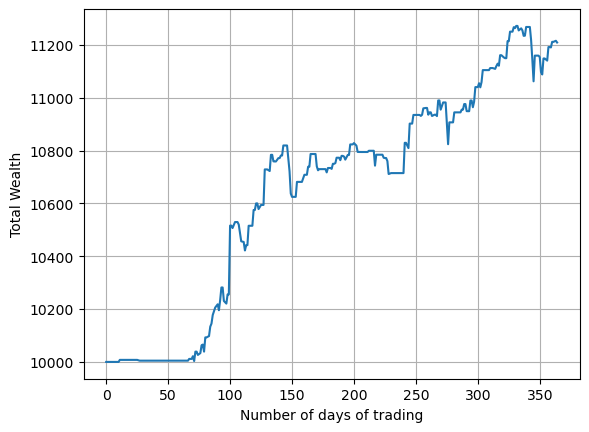

In [ ]:
fig = plt.plot(W[:,0], W[:, 1])
plt.grid()
plt.xlabel("Number of days of trading")
plt.ylabel('Total Wealth');

In [21]:
# Extract the wealth series from the backtest output.
wealth_array = W[:, 1]

# Compute daily portfolio returns.
returns = wealth_array[1:] / wealth_array[:-1] - 1

mean_daily_return = np.mean(returns)
std_daily_return = np.std(returns, ddof=1)

if std_daily_return > 0:
    sharpe_ratio = mean_daily_return / std_daily_return * np.sqrt(252)
else:
    sharpe_ratio = 0

total_return = wealth_array[-1] / wealth_array[0] - 1

print(f"Initial wealth:           {wealth_array[0]:.2f}")
print(f"Final wealth:             {wealth_array[-1]:.2f}")
print(f"Total return:             {total_return:.2%}")
print(f"Mean daily return:        {mean_daily_return:.4f}")
print(f"Std. dev. daily return:   {std_daily_return:.4f}")
print(f"Sharpe ratio:             {sharpe_ratio:.4f}")

Initial wealth:           10000.00
Final wealth:             11208.70
Total return:             12.09%
Mean daily return:        0.0004
Std. dev. daily return:   0.0027
Sharpe ratio:             2.1730


## Conclusion

This notebook successfully implements a momentum-based trading strategy for the S&P 500 using a Geometric Brownian Motion model.

The project satisfies the required coursework components:

- loading price data from CSV into SQLite
- creating the `prices` and `positions` tables
- calibrating a GBM model from log returns
- estimating the first and second moments through repeated sampling
- forecasting the future price with a confidence interval
- calculating expected shortfall
- running a backtest over the required test period

The final results suggest that the strategy was able to increase portfolio value over the backtest window while using a simple and interpretable risk-aware position sizing rule.